<a href="https://colab.research.google.com/github/SandraVargasAI/Mineria-de-Datos-/blob/main/MD_C9_Ejercicio_Integrador_(Secci%C3%B3n_4)_(SV).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Sección 4: Ejercicio Integrador**

**Objetivo**: Aplicar los conceptos aprendidos sobre Árboles de Decisión en un caso práctico, optimizar su rendimiento y compartir los resultados en el foro.

## Ejercicio Integrador: Predicción de Riesgo Crediticio

**Contexto**: Un banco quiere construir un modelo para predecir si un cliente incumplirá en el pago de un crédito. Los datos incluyen información sobre ingresos, edad, historial crediticio y monto del préstamo solicitado.

**Dataset para el ejercicio**
| Variable | Descripción | Tipo |
|---|---|---|
| Edad | Edad del cliente | Numérica |
| Ingresos ($USD) | Ingresos anuales en dólares | Numérica |
| Historial | Cantidad de deudas previas | Numérica |
| Monto Crédito | Monto del préstamo solicitado | Numérica |
| Incumplimiento | 1 = No pagó el préstamo, 0 = Sí pagó | Categórica (Sí/No) |

**Tareas a Realizar:**

1. **Preprocesamiento de Datos**: Normalizar las variables numéricas. Dividir en entrenamiento (80%) y prueba (20%).
2. **Entrenar un Árbol de Decisión Básico**: Utilizar *DecisionTreeClassifier* con hiperparámetros por defecto. Evaluar el modelo con Precisión y Matriz de Confusión.
3. **Optimizar el Modelo**: Ajustar *max_depth, min_samples_split y min_samples_leaf* usando GridSearchCV. Evaluar la mejora en precisión y sobreajuste.
4. **Comparar con otro Modelo (Regresión Logística o Random Forest)**: Entrenar un Random Forest y comparar sus métricas con el árbol de decisión.
5. **Interacción con una Herramienta de IA (ChatGPT, Gemini, Copilot)**: Consultar cómo mejorar el modelo y comparar la respuesta con lo aprendido. Ejemplo de consulta: "Estoy entrenando un árbol de decisión para predecir incumplimiento de crédito. ¿Qué técnicas de optimización recomendarías?"


In [106]:
# Cargamos las Librerías a utilizar
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [107]:
# Simulación de datos de clientes de un banco
# Creación del dataset
data = {
    "Edad": np.random.randint(20, 65, 500),
    "Ingresos": np.random.randint(20000, 120000, 500),
    "Historial": np.random.randint(0, 5, 500),
    "Monto_Credito": np.random.randint(5000, 50000, 500),
    "Incumplimiento": np.random.choice([0, 1], size=500, p=[0.7, 0.3])  # 30% de incumplimiento
}
df = pd.DataFrame(data)

display(df.head())

,Edad,Ingresos,Historial,Monto_Credito,Incumplimiento
0,31,93610,1,29645,0
1,60,25012,0,26077,1
2,62,28178,0,34134,0
3,34,76811,1,12993,0
4,33,96158,0,35905,0


In [108]:
# Exploración Inicial de los datos
print("\n------ Valores Nulos: \n", df.isnull().sum())
df.describe()


------ Valores Nulos: 
 Edad              0
Ingresos          0
Historial         0
Monto_Credito     0
Incumplimiento    0
dtype: int64


,Edad,Ingresos,Historial,Monto_Credito,Incumplimiento
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,41.828000,69920.618000,1.990000,27954.840000,0.318000
std,13.291491,28922.489459,1.412051,13672.667243,0.466166
min,20.000000,20077.000000,0.000000,5032.000000,0.000000
25%,30.000000,43560.000000,1.000000,14920.750000,0.000000
50%,41.500000,70585.500000,2.000000,29018.500000,0.000000
75%,54.000000,95204.000000,3.000000,39911.750000,1.000000
max,64.000000,119946.000000,4.000000,49959.000000,1.000000


In [109]:
# Variable Objetivo - Cantidades
df["Incumplimiento"].value_counts()

,count
Incumplimiento,
0,341
1,159


In [110]:
# Creación de variables predictora y variable objetivo
X = df.drop(columns=["Incumplimiento"])
y = df["Incumplimiento"]

**1. Preprocesamiento de Datos:** Normalizar las variables numéricas. Dividir en entrenamiento (80%) y prueba (20%).

In [111]:
# Normalizar las variables numéricas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

display(X_scaled.head())

,Edad,Ingresos,Historial,Monto_Credito
0,-0.815472,0.819885,-0.701810,0.123740
1,1.368560,-1.554278,-1.410709,-0.137480
2,1.519183,-1.444704,-1.410709,0.452388
3,-0.589538,0.238475,-0.701810,-1.095384
4,-0.664849,0.908070,-1.410709,0.582046


In [112]:
# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, stratify=y, test_size=0.2, random_state=42)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (400, 4)
Prueba: (100, 4)


**2. Entrenar un Árbol de Decisión Básico:** Utilizar DecisionTreeClassifier con hiperparámetros por defecto. Evaluar el modelo con Precisión y Matriz de Confusión.

In [113]:
# Entrenar Árbol de Decisión Básico
tree_basico = DecisionTreeClassifier(random_state=42)
tree_basico.fit(X_train, y_train)

# Predicciones y evaluación
y_pred_tbasico = tree_basico.predict(X_test)

print("----- Evaluación - Árbol Básico\n")
print("Precisión:", accuracy_score(y_test, y_pred_tbasico))
print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred_tbasico))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred_tbasico))

----- Evaluación - Árbol Básico

Precisión: 0.56

Matriz de Confusión:
 [[48 20]
 [24  8]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.67      0.71      0.69        68
           1       0.29      0.25      0.27        32

    accuracy                           0.56       100
   macro avg       0.48      0.48      0.48       100
weighted avg       0.54      0.56      0.55       100



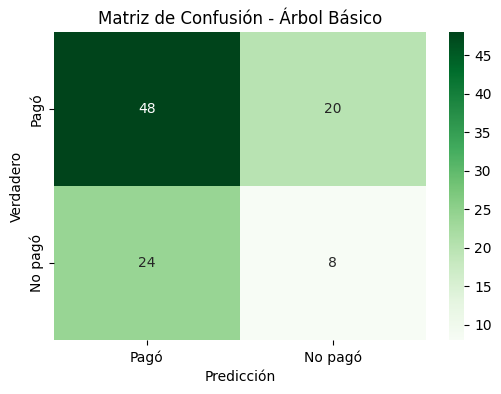

In [114]:
# Visualización de la Matriz de Confisión
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_tbasico), annot=True, fmt="d", cmap="Greens", xticklabels=["Pagó", "No pagó"],
    yticklabels=["Pagó", "No pagó"])
plt.xlabel("Predicción")
plt.ylabel("Verdadero")
plt.title("Matriz de Confusión - Árbol Básico")
plt.show()

**3. Optimizar el Modelo:** Ajustar max_depth, min_samples_split y min_samples_leaf usando GridSearchCV. Evaluar la mejora en precisión y sobreajuste.

In [115]:
# Optimización con GridSearchCV
# Parámetros
param_grid = {
    "max_depth": [3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 5, 10]
}

# Aplicar GridSearchCV
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring="accuracy")
grid_search.fit(X_train, y_train)

print("Mejores Parámetros:", grid_search.best_params_)

Mejores Parámetros: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [116]:
# Evaluar Árbol Optimizado
best_tree = grid_search.best_estimator_

y_pred_opt = best_tree.predict(X_test)

print("----- Evaluación - Árbol Optimizado\n")
print("Precisión:", accuracy_score(y_test, y_pred_opt))
print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred_opt))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred_opt))

----- Evaluación - Árbol Optimizado

Precisión: 0.64

Matriz de Confusión:
 [[60  8]
 [28  4]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.68      0.88      0.77        68
           1       0.33      0.12      0.18        32

    accuracy                           0.64       100
   macro avg       0.51      0.50      0.48       100
weighted avg       0.57      0.64      0.58       100



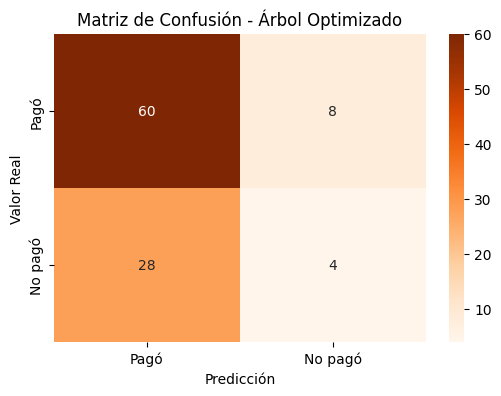

In [117]:
# Visualización de la Matriz de Consusión
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_opt), annot=True, fmt="d", cmap="Oranges", xticklabels=["Pagó", "No pagó"],
    yticklabels=["Pagó", "No pagó"])
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión - Árbol Optimizado")
plt.show()

**4. Comparar con otro Modelo (Regresión Logística o Random Forest):** Entrenar un Random Forest y comparar sus métricas con el árbol de decisión.

In [118]:
# Comparación con el modelo Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("----- Evaluación - Random Forest\n")
print("Precisión:", accuracy_score(y_test, y_pred_rf))
print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred_rf))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred_rf))

----- Evaluación - Random Forest

Precisión: 0.62

Matriz de Confusión:
 [[57 11]
 [27  5]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.68      0.84      0.75        68
           1       0.31      0.16      0.21        32

    accuracy                           0.62       100
   macro avg       0.50      0.50      0.48       100
weighted avg       0.56      0.62      0.58       100



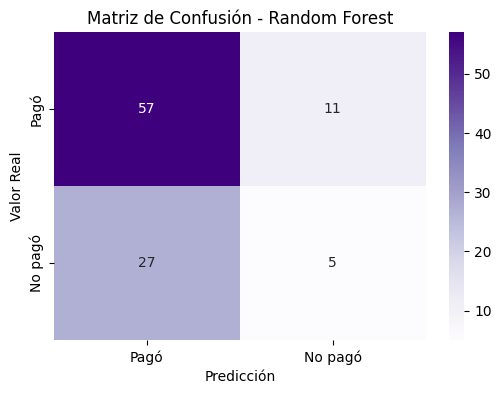

In [119]:
# Visualización de la Matriz de Confisión - Random Forest
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Purples", xticklabels=["Pagó", "No pagó"],
    yticklabels=["Pagó", "No pagó"])
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión - Random Forest")
plt.show()

In [120]:
# Comparación de métricas de los tres modelos: árbol básico, árbol optimizado y random forest
# Comparar accuracy_score
print("Comparación de Precisión:")
print("Árbol Básico:", accuracy_score(y_test, y_pred_tbasico))
print("Árbol Optimizado:", accuracy_score(y_test, y_pred_opt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Comparación de Precisión:
Árbol Básico: 0.56
Árbol Optimizado: 0.64
Random Forest: 0.62


# Visualización de Matriz de Confusión de los tres modelos.

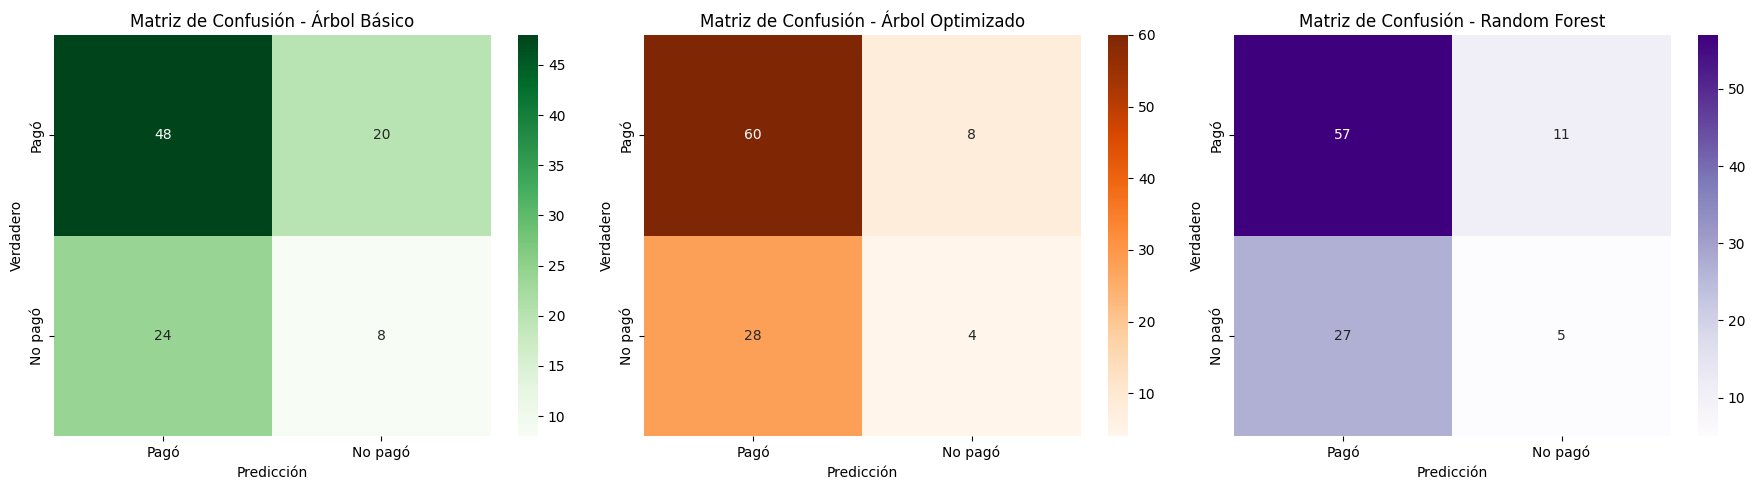

In [121]:
# Visualización de Matriz de Confusión de los tres modelos
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_tbasico), annot=True, fmt="d", cmap="Greens", xticklabels=["Pagó", "No pagó"],
    yticklabels=["Pagó", "No pagó"])
plt.xlabel("Predicción")
plt.ylabel("Verdadero")
plt.title("Matriz de Confusión - Árbol Básico")

plt.subplot(1, 3, 2)
sns.heatmap(confusion_matrix(y_test, y_pred_opt), annot=True, fmt="d", cmap="Oranges", xticklabels=["Pagó", "No pagó"],
    yticklabels=["Pagó", "No pagó"])
plt.xlabel("Predicción")
plt.ylabel("Verdadero")
plt.title("Matriz de Confusión - Árbol Optimizado")

plt.subplot(1, 3, 3)
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Purples", xticklabels=["Pagó", "No pagó"],
    yticklabels=["Pagó", "No pagó"])
plt.xlabel("Predicción")
plt.ylabel("Verdadero")
plt.title("Matriz de Confusión - Random Forest")

plt.tight_layout()
plt.show()

# Visualización Árbol de Decisión de los tres modelos.

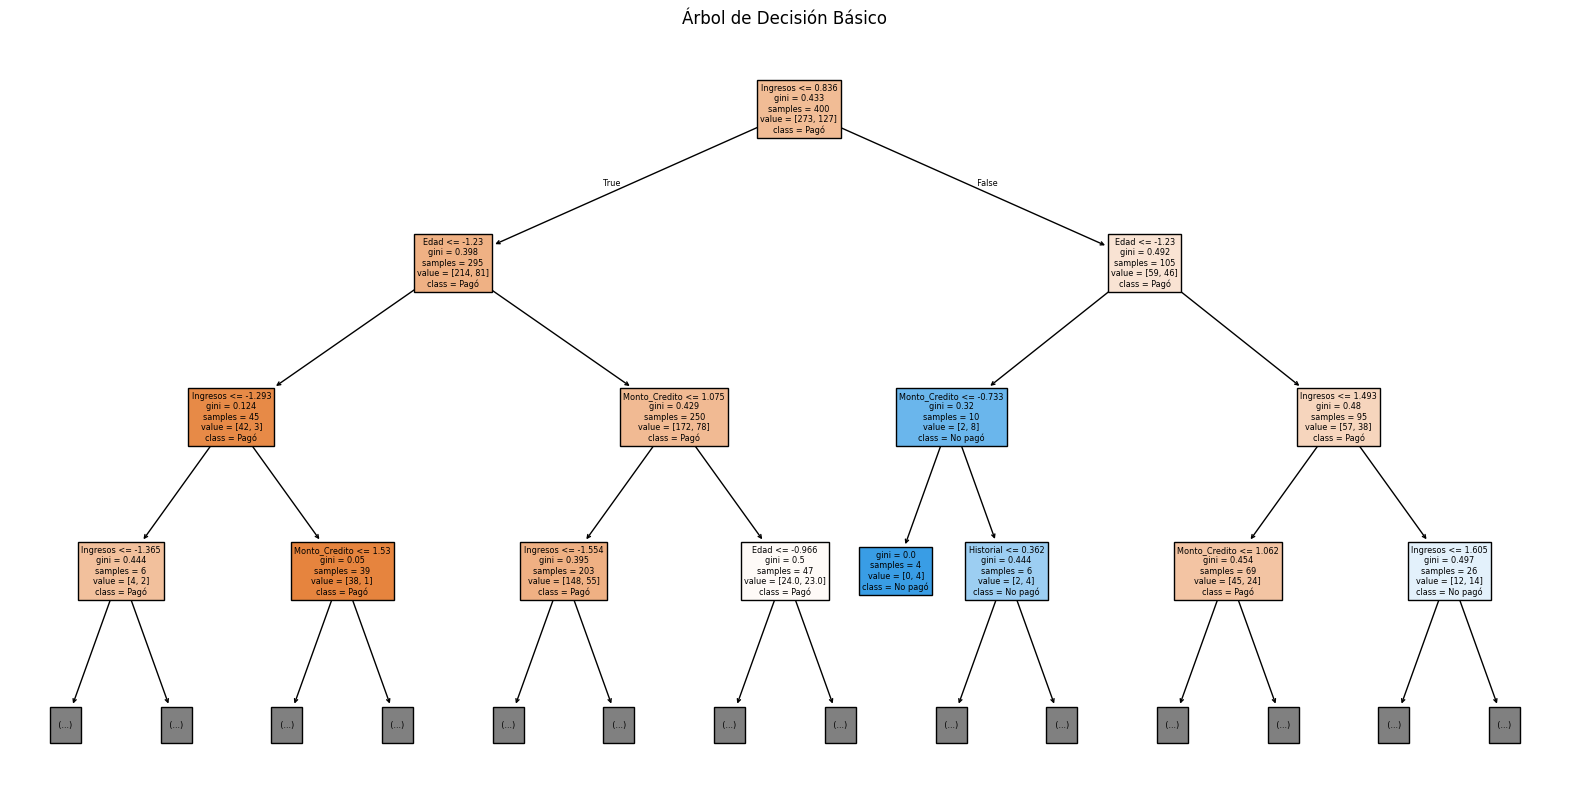

In [122]:
plt.figure(figsize=(20, 10))
plot_tree(tree_basico, filled=True, feature_names=X.columns, class_names=["Pagó", "No pagó"], max_depth=3)
plt.title("Árbol de Decisión Básico")
plt.show()

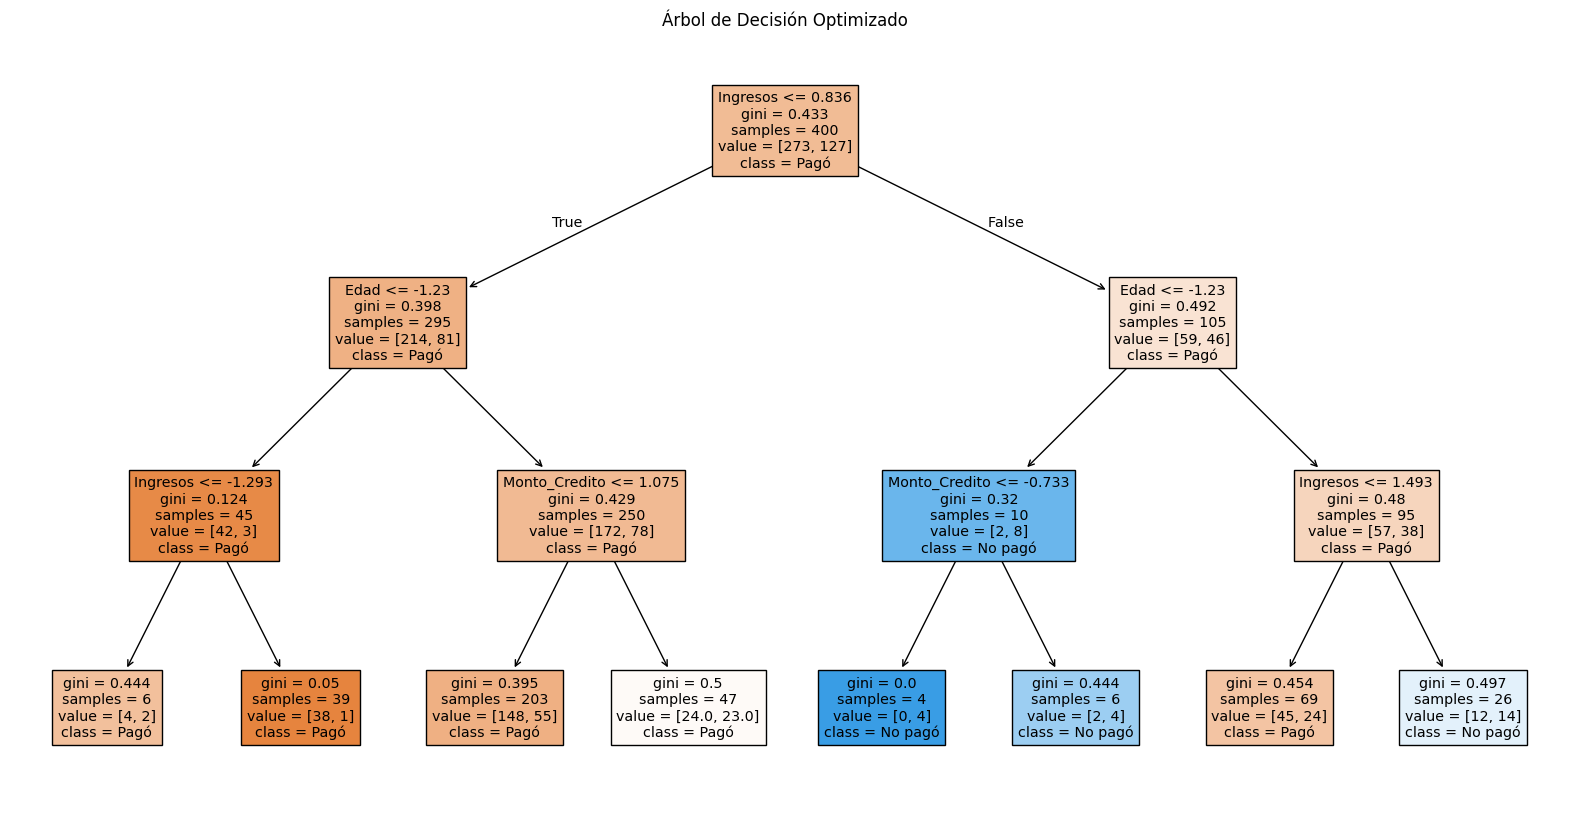

In [123]:
plt.figure(figsize=(20, 10))
plot_tree(best_tree, filled=True, feature_names=X.columns, class_names=["Pagó", "No pagó"])
plt.title("Árbol de Decisión Optimizado")
plt.show()

Para el Random Forest, visualizaremos uno de los árboles que lo componen.

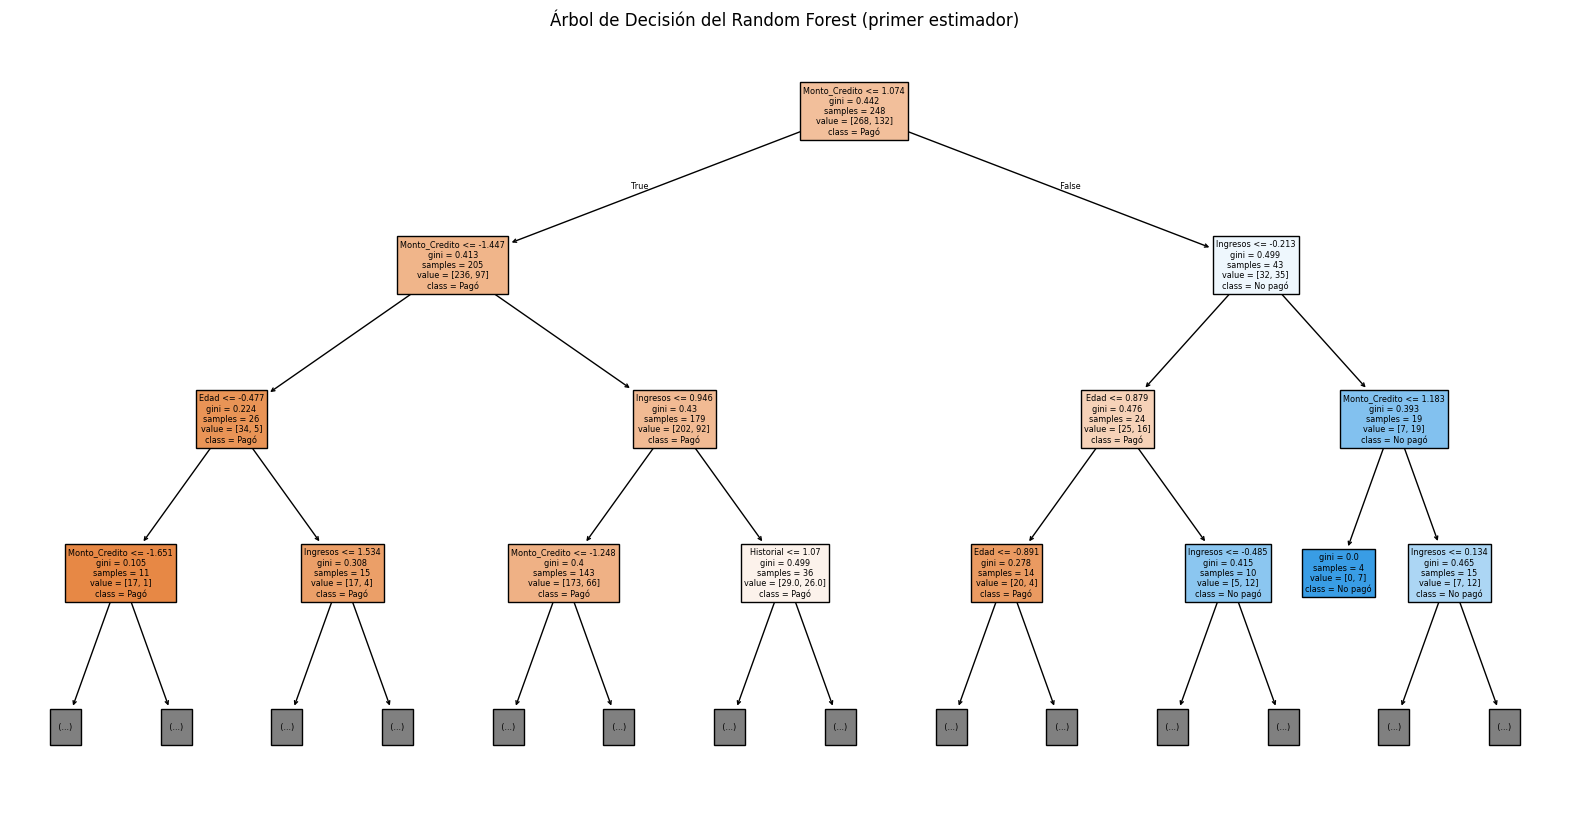

In [124]:
plt.figure(figsize=(20, 10))
plot_tree(rf.estimators_[0], filled=True, feature_names=X.columns, class_names=["Pagó", "No pagó"], max_depth=3)
plt.title("Árbol de Decisión del Random Forest (primer estimador)")
plt.show()

**Interacción con una Herramienta de IA (ChatGPT, Gemini, Copilot):** Consultar cómo mejorar el modelo y comparar la respuesta con lo aprendido. Ejemplo de consulta: "Estoy entrenando un árbol de decisión para predecir incumplimiento de crédito. ¿Qué técnicas de optimización recomendarías?"

**Respuesta Obtenida**

Para optimizar un árbol de decisión en la predicción de incumplimiento de crédito, se pueden aplicar varias técnicas. La poda reduce el sobreajuste limitando la complejidad del árbol mediante parámetros como la profundidad máxima y el tamaño mínimo de los nodos. Los métodos de conjunto, como Random Forest y Gradient Boosting, mejoran la precisión al combinar múltiples árboles. La validación cruzada permite evaluar y ajustar el modelo de forma más confiable. La ingeniería de características ayuda a crear variables más informativas para mejorar las predicciones. Además, en conjuntos de datos desbalanceados, es importante aplicar técnicas como SMOTE, ajuste de pesos de clase y el uso de métricas adecuadas como F1-score y AUC-ROC.

**Comparación con lo aprendido en clase**

La respusta de la IA, coincide bastante con lo visto y realizado en este trabajo. Ajustamos paármetros para trabajr la profundidad y realizamos una comparación con random forest. Las métrica utilizadas son un factor clave en este tipo de problemas, ya que no queremos considerar a un cliente con una categoría erronea.

**Conclusión**:

  * El Árbol de Decisión optimizado, superar al modelo básico y evita el sobreajuste.
  * El Random Forest podría mejorar la predicción, pero con mayor complejidad computacional.
